In [1]:
import numpy as np
import pandas as pd
import yfinance as yf
import scipy.optimize as sco
import matplotlib.pyplot as plt

In [2]:
class DiversificationOptimizer:
    def __init__(self, covariance_matrix):
        self.cov = np.array(covariance_matrix)
        self.n_assets = self.cov.shape[0]
        self.vols = np.sqrt(np.diag(self.cov))

    def _dr_objective(self, weights):
        port_vol = np.sqrt(np.dot(weights.T, np.dot(self.cov, weights)))
        weighted_vols = np.dot(weights.T, self.vols)
        return -(weighted_vols / port_vol)

    def optimize_mdp(self):
        x0 = np.ones(self.n_assets) / self.n_assets
        constraints = ({'type': 'eq', 'fun': lambda x: np.sum(x) - 1.0})
        bounds = tuple((0.0, 1.0) for _ in range(self.n_assets))

        result = sco.minimize(self._dr_objective, x0, method='SLSQP',
                              bounds=bounds, constraints=constraints)
        return result.x

    def _variance_objective(self, weights):
        return np.dot(weights.T, np.dot(self.cov, weights))

    def optimize_gmv(self):
        x0 = np.ones(self.n_assets) / self.n_assets
        constraints = ({'type': 'eq', 'fun': lambda x: np.sum(x) - 1.0})
        bounds = tuple((0.0, 1.0) for _ in range(self.n_assets))

        result = sco.minimize(self._variance_objective, x0, method='SLSQP',
                              bounds=bounds, constraints=constraints)
        return result.x

In [3]:
# ==========================================
# 1. Data Ingestion & Preprocessing
# ==========================================

# 40 Prominent Nifty 50 Tickers (Yahoo Finance Format)
tickers = [
    'RELIANCE.NS', 'TCS.NS', 'HDFCBANK.NS', 'ICICIBANK.NS', 'INFY.NS',
    'ITC.NS', 'SBIN.NS', 'BHARTIARTL.NS', 'LT.NS', 'BAJFINANCE.NS',
    'HINDUNILVR.NS', 'AXISBANK.NS', 'KOTAKBANK.NS', 'MARUTI.NS', 'SUNPHARMA.NS',
    'TATASTEEL.NS', 'ASIANPAINT.NS', 'BAJAJFINSV.NS', 'TITAN.NS',
    'WIPRO.NS', 'ULTRACEMCO.NS', 'ONGC.NS', 'NESTLEIND.NS', 'TECHM.NS',
    'HINDALCO.NS', 'JSWSTEEL.NS', 'POWERGRID.NS', 'NTPC.NS', 'GRASIM.NS',
    'CIPLA.NS', 'APOLLOHOSP.NS', 'BRITANNIA.NS', 'INDUSINDBK.NS',
    'EICHERMOT.NS', 'DIVISLAB.NS', 'DRREDDY.NS', 'HEROMOTOCO.NS', 'HDFCLIFE.NS'
]

print("Downloading data...")
# Fetch data from Jan 2018 through Dec 2024
data = yf.download(tickers, start='2018-01-01', end='2024-12-31')

# Extract 'Close' prices and drop any stocks that might not have full history
prices = data['Close'].dropna(axis=1)
valid_tickers = prices.columns.tolist()
print(f"Successfully loaded full history for {len(valid_tickers)} stocks.")

# Calculate daily logarithmic returns
returns = np.log(prices / prices.shift(1)).dropna()

/tmp/ipykernel_1198/1058205639.py:19: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(tickers, start='2018-01-01', end='2024-12-31')
[*********************100%***********************]  38 of 38 completed

Successfully loaded full history for 38 stocks.


In [4]:
# ==========================================
# 2. Train/Test Split
# ==========================================

# Train: Jan 2018 to Dec 2023
train_returns = returns.loc['2018-01-01':'2023-12-31']
# Test: Jan 2024 to Dec 2025
test_returns = returns.loc['2024-01-01':'2024-12-31']

In [5]:
# ==========================================
# 3. Training: Model Optimization
# ==========================================

print("\nOptimizing portfolios on 2018-2023 data...")
# Annualize the training covariance matrix (252 trading days)
train_cov_matrix = train_returns.cov() * 252

optimizer = DiversificationOptimizer(train_cov_matrix)
mdp_weights = optimizer.optimize_mdp()
gmv_weights = optimizer.optimize_gmv()
equal_weights = np.ones(len(valid_tickers)) / len(valid_tickers)

# Display Top 5 Holdings for MDP
weights_df = pd.DataFrame({'Asset': valid_tickers, 'MDP_Weight': mdp_weights, 'GMV_Weight': gmv_weights})
top_mdp = weights_df.sort_values(by='MDP_Weight', ascending=False).head(5)
print("\nTop 5 MDP Holdings (Train Period):")
print(top_mdp.to_string(index=False))


Optimizing portfolios on 2018-2023 data...

Top 5 MDP Holdings (Train Period):
       Asset  MDP_Weight  GMV_Weight
POWERGRID.NS    0.101979    0.126611
    CIPLA.NS    0.085195    0.093829
  DRREDDY.NS    0.079238    0.089274
     ONGC.NS    0.069714    0.002412
      TCS.NS    0.069506    0.119384


In [6]:
# ==========================================
# 4. Testing: Out-of-Sample Performance
# ==========================================

print("\nRunning Out-of-Sample Backtest (2024-2025)...")

# Calculate daily portfolio returns for the test period
# Dot product of daily asset returns and our fixed weights
test_port_mdp = test_returns.dot(mdp_weights)
test_port_gmv = test_returns.dot(gmv_weights)
test_port_eq = test_returns.dot(equal_weights)

# Calculate cumulative returns (Equity Curve)
cum_mdp = np.exp(test_port_mdp.cumsum())
cum_gmv = np.exp(test_port_gmv.cumsum())
cum_eq = np.exp(test_port_eq.cumsum())

# Performance Metrics Function
def calc_metrics(daily_returns, name):
    ann_ret = daily_returns.mean() * 252
    ann_vol = daily_returns.std() * np.sqrt(252)
    sharpe = ann_ret / ann_vol
    return {'Portfolio': name, 'Return (Ann)': f"{ann_ret*100:.2f}%",
            'Volatility (Ann)': f"{ann_vol*100:.2f}%", 'Sharpe': f"{sharpe:.2f}"}

metrics = pd.DataFrame([
    calc_metrics(test_port_mdp, "Maximum Diversification (MDP)"),
    calc_metrics(test_port_gmv, "Global Minimum Variance (GMV)"),
    calc_metrics(test_port_eq, "Equal Weight (1/N)")
])

print("\n--- Out-of-Sample Performance (Jan 2024 - Dec 2024) ---")
print(metrics.to_string(index=False))


Running Out-of-Sample Backtest (2024-2025)...

--- Out-of-Sample Performance (Jan 2024 - Dec 2024) ---
                    Portfolio Return (Ann) Volatility (Ann) Sharpe
Maximum Diversification (MDP)       12.88%           12.41%   1.04
Global Minimum Variance (GMV)        7.54%           11.84%   0.64
           Equal Weight (1/N)        7.64%           13.21%   0.58


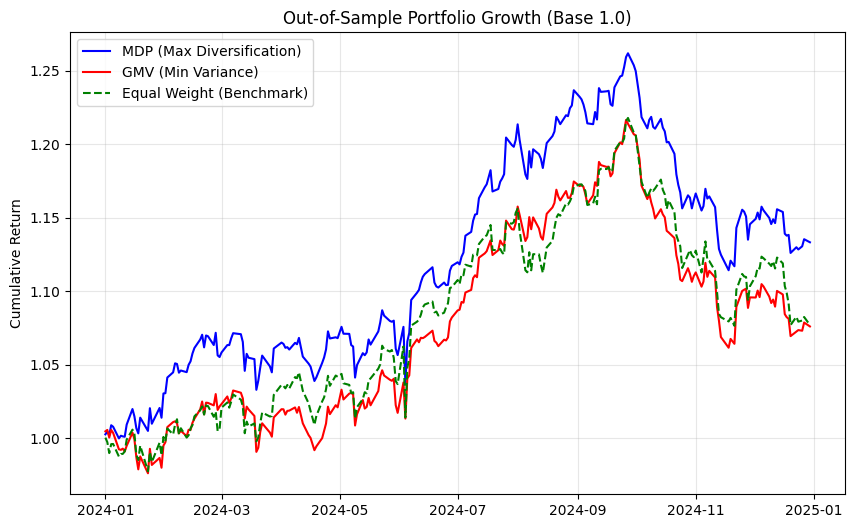

In [7]:
# ==========================================
# 5. Visualization
# ==========================================

plt.figure(figsize=(10, 6))
plt.plot(cum_mdp.index, cum_mdp, label='MDP (Max Diversification)', color='blue')
plt.plot(cum_gmv.index, cum_gmv, label='GMV (Min Variance)', color='red')
plt.plot(cum_eq.index, cum_eq, label='Equal Weight (Benchmark)', color='green', linestyle='--')
plt.title('Out-of-Sample Portfolio Growth (Base 1.0)')
plt.ylabel('Cumulative Return')
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()